In [1]:
# Improting the Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Loading the Dataset
data = pd.read_csv('Financial Budget Analysis.csv')

In [5]:
# Analyse the Top 5 rows of the Data
data.head()

,Department /Ministry,Fund allotted(in ₹crores)
0,MINISTRY OF AGRICULTURE,131531.19
1,DEPARTMENT OF ATOMIC ENERGY,18264.89
2,"MINISTRY OF AYURVEDA, YOGA",2970.30
3,MINISTRY OF CHEMICALS AND FERTILISER,80714.94
4,MINISTRY OF CIVIL AVIATION,3224.67


In [7]:
data

,Department /Ministry,Fund allotted(in ₹crores)
0,MINISTRY OF AGRICULTURE,131531.19
1,DEPARTMENT OF ATOMIC ENERGY,18264.89
2,"MINISTRY OF AYURVEDA, YOGA",2970.30
3,MINISTRY OF CHEMICALS AND FERTILISER,80714.94
4,MINISTRY OF CIVIL AVIATION,3224.67
5,MINISTRY OF COAL,534.88
6,MINISTRY OF COMMERCE AND INDUSTRY,12768.25
7,MINISTRY OF COMMUNICATION,75265.22
8,MINISTRY OF CONSUMER AFFAIRS,256948.40
9,MINISTRY OF CORPORATE AFFAIRS,712.13


In [9]:
# We can see a NaN value in this dataset, let’s remove the NaN values and continue with the task of financial budget analysis
data.dropna()

,Department /Ministry,Fund allotted(in ₹crores)
0,MINISTRY OF AGRICULTURE,131531.19
1,DEPARTMENT OF ATOMIC ENERGY,18264.89
2,"MINISTRY OF AYURVEDA, YOGA",2970.30
3,MINISTRY OF CHEMICALS AND FERTILISER,80714.94
4,MINISTRY OF CIVIL AVIATION,3224.67
5,MINISTRY OF COAL,534.88
6,MINISTRY OF COMMERCE AND INDUSTRY,12768.25
7,MINISTRY OF COMMUNICATION,75265.22
8,MINISTRY OF CONSUMER AFFAIRS,256948.40
9,MINISTRY OF CORPORATE AFFAIRS,712.13


##### We can see that not all the departments that are covered in this dataset are the main departments, as some departments can be covered in the others category.

In [16]:
# So let’s prepare the data by only selecting the main departments and putting all the other departments in the other category
valid_indices = [i for i in [0, 8, 11, 14, 18, 23, 41, 42, 43] if i < len(data)]
data = data.iloc[valid_indices, :]

new_row = pd.DataFrame([{'Department /Ministry': 'OTHERS', 'Fund allotted(in ₹crores)': 592971.0800000001}])
data = pd.concat([data, new_row], ignore_index=True)

print(data)


            Department /Ministry  Fund allotted(in ₹crores)
0        MINISTRY OF AGRICULTURE                  131531.19
1  MINISTRY OF RURAL DEVELOPMENT                  133689.50
2                         OTHERS                  592971.08


<Axes: xlabel='Department /Ministry'>

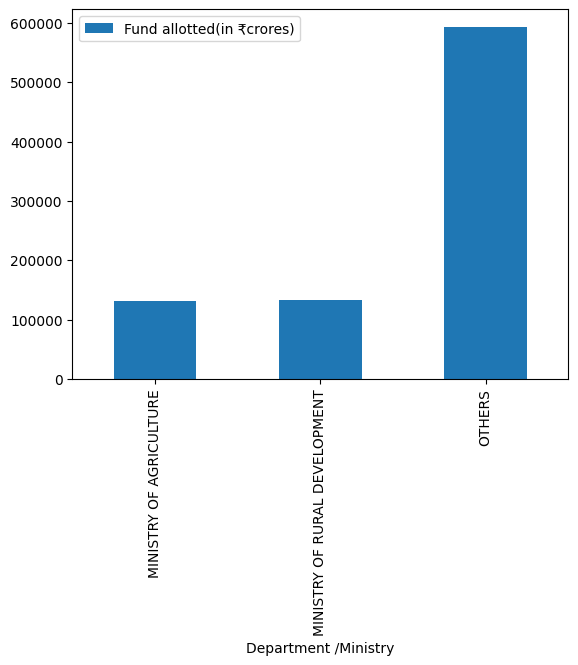

In [18]:
# Now let’s plot this data to have a look at the priorities of the government for the financial year
data.plot.bar(x='Department /Ministry', y='Fund allotted(in ₹crores)')

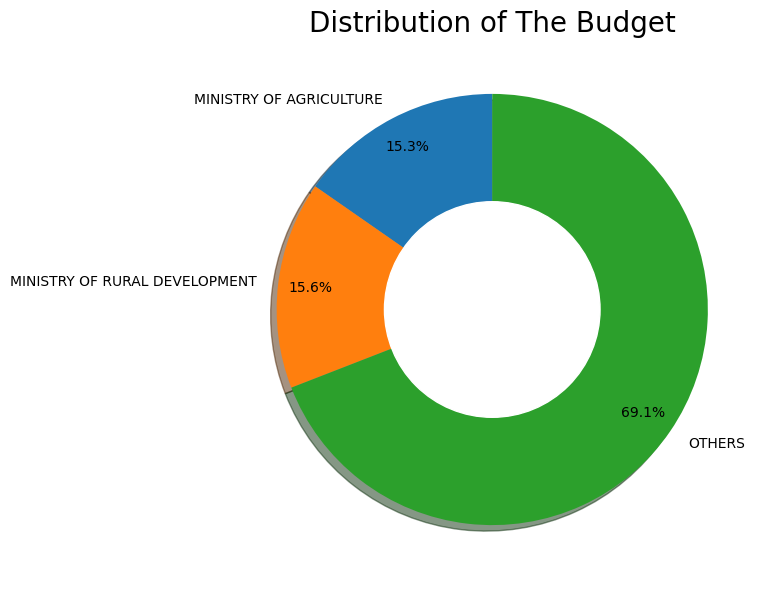

In [20]:
df = data["Fund allotted(in ₹crores)"]
labels = data["Department /Ministry"]
plt.figure(figsize=(7,7))
plt.pie(df, labels=labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85, shadow =True)
central_circle = plt.Circle((0, 0), 0.5, color='white')
fig = plt.gcf()
fig.gca().add_artist(central_circle)
plt.rc('font', size=12)
plt.title("Distribution of The Budget", fontsize=20)
plt.show()